# Cross-sample alignment - two breast cancer sections from Xenium

This notebook aligns the Rep2 query section to the fixed Rep1
reference using the selected BANKSY `lambda=0.2`, Harmony and
Leiden result. It uses the recorded manual similarity transform
as the global initialization, with optional interactive controls
for adapting the transform to another pair of sections.

**Fixed-seed reproducibility.** This workflow uses seed `1000`. Use the same input observations in the same order and the same workflow parameters, and set the seed before the first stochastic step. Two independent runs with these settings reproduced the reported output.

## Current input and preprocessing

The current input contains 279,625 QC-passing cells and 313
`Gene Expression` features. Blank, negative-control codeword and
negative-control probe features were excluded. Cells were filtered
at at least 20 gene counts, at least 10 detected genes and at most
5% controls. Counts were normalized to 10,000 per cell and `log1p`
transformed; raw gene counts remain in `layers["counts"]`.

No HVG selection was applied because only 313 biological genes
remain. The alignment channels are the 10 shared Leiden clusters
from BANKSY `lambda=0.2`, Harmony `theta=4` and Leiden resolution
`0.3`.

In [1]:
%matplotlib inline

from pathlib import Path
import json
import os
import sys
import warnings

import anndata as ad
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from scipy.spatial import cKDTree


def locate_repository(start: Path):
    start = start.resolve()
    for candidate in (start, *start.parents):
        docs_root = candidate / "pipeline" / "FF" / "docs"
        if (docs_root / "pyproject.toml").is_file():
            return candidate, docs_root
        if (
            (candidate / "pyproject.toml").is_file()
            and (candidate / "src" / "spalignde").is_dir()
        ):
            nested_docs = (
                candidate.name == "docs"
                and candidate.parent.name == "FF"
                and candidate.parent.parent.name == "pipeline"
            )
            repo_root = candidate.parents[2] if nested_docs else candidate
            return repo_root, candidate
    raise FileNotFoundError("Run this notebook from inside the spAlignDE repository")


REPO_ROOT, DOCS_ROOT = locate_repository(Path.cwd())
PACKAGE_SRC = DOCS_ROOT / "src"
if str(PACKAGE_SRC) not in sys.path:
    sys.path.insert(0, str(PACKAGE_SRC))

import spAlignDE

WORKFLOW_SEED = 1000
seed_controls = spAlignDE.set_random_seed(
    WORKFLOW_SEED,
    deterministic_torch=True,
)

SUPP_DIR = (
    REPO_ROOT
    / "pipeline"
    / "FF"
    / "Supp"
    / "breast_cancer"
    / "0803"
    / "lambda_0p2"
)
DOC_OUTPUT_DIR = (
    REPO_ROOT / "outputs" / "breast_cancer_xenium" / "lambda_0p2"
)
cwd = Path.cwd().resolve()
default_output = SUPP_DIR if cwd == SUPP_DIR else DOC_OUTPUT_DIR
OUTPUT_DIR = Path(
    os.environ.get("SPALIGNDE_BREAST_CANCER_ALIGNMENT_OUTPUT", default_output)
).expanduser().resolve()
default_input = OUTPUT_DIR / "breast_cancer_Rep1_Rep2_lambda_0p2_clustered.h5ad"
if not default_input.exists():
    default_input = OUTPUT_DIR / "breast_cancer_Rep1_Rep2_joint_clustered.h5ad"
clustered_path = Path(
    os.environ.get("SPALIGNDE_BREAST_CANCER_CLUSTERED_H5AD", default_input)
).expanduser().resolve()

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans", "sans-serif"],
    "font.size": 8,
    "axes.spines.right": False,
    "axes.spines.top": False,
    "legend.frameon": False,
    "svg.fonttype": "none",
    "pdf.fonttype": 42,
})

adata = ad.read_h5ad(clustered_path)
spAlignDE.validate_cross_sample_anndata(adata, cluster_key="cluster")
QUERY = "Rep2"
REFERENCE = "Rep1"
print(adata)
print(adata.obs["sample_id"].value_counts().sort_index())
print("Genes:", adata.n_vars)
print("HVG selection:", adata.uns["clustering"]["hvg_selection"])
public_preprocessing = {
    key: value
    for key, value in adata.uns["preprocessing"].items()
    if key not in {"input_data_dir", "official_cells_dir", "output_dir"}
}
print("Preprocessing:", public_preprocessing)

AnnData object with n_obs × n_vars = 279625 × 313
    obs: 'cell_id', 'x', 'y', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'sample_id', 'n_genes_by_counts', 'gene_counts_from_h5', 'control_counts_from_h5', 'control_fraction', 'leiden_harmony', 'cluster'
    var: 'feature_type'
    uns: 'clustering', 'log1p', 'preprocessing'
    obsm: 'X_harmony_banksy', 'X_pca_banksy', 'X_umap_after_harmony', 'X_umap_before_harmony', 'spatial'
    layers: 'counts'
sample_id
Rep1    161995
Rep2    117630
Name: count, dtype: int64
Genes: 313
HVG selection: False
Preprocessing: {'banksy_decay': 'scaled_gaussian', 'banksy_max_m': 1, 'banksy_neighbors': 30, 'features_used': 'Gene Expression only', 'graph_neighbors': 50, 'harmony_max_iter': 30, 'harmony_theta': 4.0, 'hvg_selection': False, 'lambdas': array([0. , 0.2, 0.5, 0.8, 1. ]), 'leiden_resolution': 0.3, 'max_control_fraction': 0.05, 'min_counts': 20, 'min_genes': 10, 'normalize_t

## Manual pre-alignment

Set `SPALIGNDE_ENABLE_MANUAL_UI=1` before starting Jupyter to show
live scale, rotation and translation sliders. The selected run
starts from scale 1, rotation 2 degrees, x translation -250 and y
translation 1750 micrometers. The following cell remains
non-interactive during automated notebook execution.

In [2]:
selected_config = spAlignDE.ManualPrealignmentConfig(
    scale=float(os.environ.get("SPALIGNDE_MANUAL_SCALE", 1.0)),
    theta_deg=float(os.environ.get("SPALIGNDE_MANUAL_THETA_DEG", 2.0)),
    translation_x=float(os.environ.get("SPALIGNDE_MANUAL_TX", -250.0)),
    translation_y=float(os.environ.get("SPALIGNDE_MANUAL_TY", 1750.0)),
)
ENABLE_MANUAL_UI = os.environ.get("SPALIGNDE_ENABLE_MANUAL_UI", "0") == "1"
manual_ui = None
if ENABLE_MANUAL_UI:
    manual_ui = spAlignDE.interactive_manual_prealignment(
        adata,
        query_sample=QUERY,
        reference_sample=REFERENCE,
        cluster_key="cluster",
        initial_config=selected_config,
        translation_radius=600,
        rotation_range_deg=8,
    )
else:
    print("Manual UI disabled; using the recorded selected transform.")

Manual UI disabled; using the recorded selected transform.


Using manual similarity pre-alignment: scale=1, theta=2.000, tx=-250.000, ty=1750.000


Selected transform: ManualPrealignmentConfig(scale=1.0, theta_deg=2.0, translation_x=-250.0, translation_y=1750.0)
Nearest-neighbor cluster agreement: 0.495


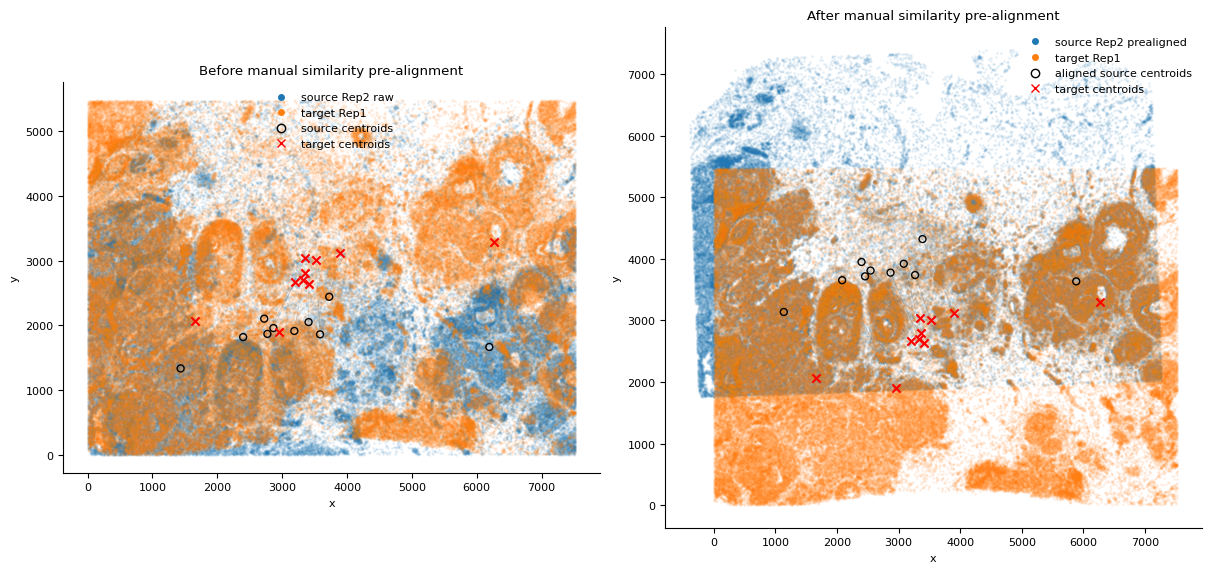

In [3]:
def nearest_label_agreement(adata, query_xy):
    sample_values = adata.obs["sample_id"].astype(str).to_numpy()
    query_values = sample_values == QUERY
    reference_values = sample_values == REFERENCE
    spatial = np.asarray(adata.obsm["spatial"])
    labels = adata.obs["cluster"].astype(str).to_numpy()
    _, indices = cKDTree(spatial[reference_values]).query(
        query_xy, k=1, workers=-1
    )
    return float(
        np.mean(labels[query_values] == labels[reference_values][indices])
    )


manual_config = manual_ui.selected_config if manual_ui is not None else selected_config
prealignment = spAlignDE.prealign_cross_sample_manual(
    adata,
    query_sample=QUERY,
    reference_sample=REFERENCE,
    cluster_key="cluster",
    config=manual_config,
)
sample = adata.obs["sample_id"].astype(str)
query_mask = sample.eq(QUERY).to_numpy()
manual_query = prealignment.adata.obs.loc[
    query_mask, ["x_prealigned", "y_prealigned"]
].to_numpy(dtype=float)
manual_agreement = nearest_label_agreement(adata, manual_query)
print("Selected transform:", manual_config)
print(f"Nearest-neighbor cluster agreement: {manual_agreement:.3f}")
spAlignDE.plot_prealignment_result(prealignment)

## Convert cells to continuous pseudo-images

The 10 shared Leiden clusters define composition channels. The
density channel is retained for visualization but receives zero
optimization weight because the serial sections have different
coverage and sampling density. A sweep over density weights 0,
0.5, 1, 2 and 4 selected zero by final cluster agreement.

Shared cluster channels: 10
Pseudo-image shape: (11, 279, 279)
Shared grid: 279 x 279


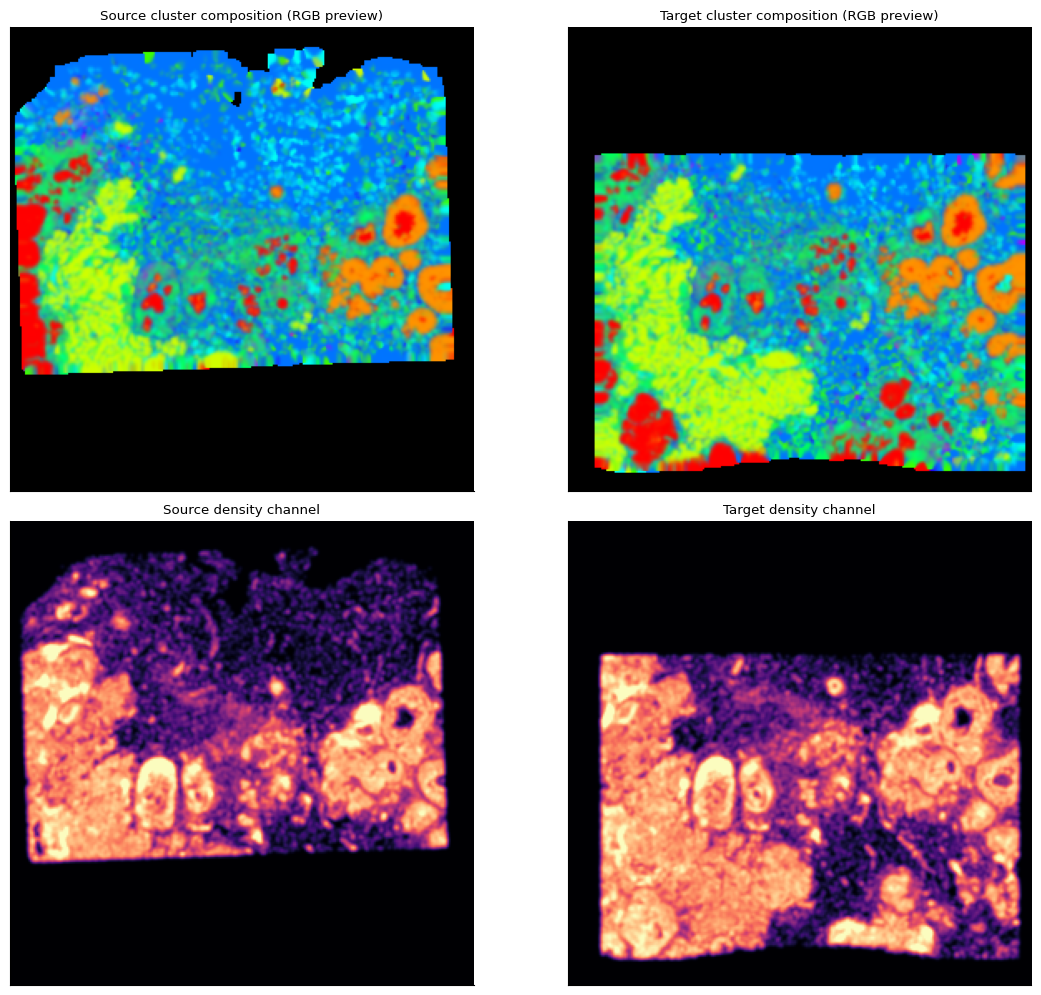

In [4]:
fields = spAlignDE.rasterize_cross_sample(
    prealignment.adata,
    query_sample=QUERY,
    reference_sample=REFERENCE,
    cluster_key="cluster",
    config=spAlignDE.RasterizationConfig(
        grid_spacing=30,
        grid_expand=1.05,
        blur_sigma=1,
        cluster_weight=1,
        density_weight=0,
    ),
)
print("Shared cluster channels:", len(fields.shared_clusters))
print("Pseudo-image shape:", fields.query_image.shape)
print("Shared grid:", len(fields.grid_y), "x", len(fields.grid_x))
spAlignDE.plot_rasterized_fields(fields)

## Shooting-based LDDMM refinement

The current run uses `a=300`, `nt=3`, `grid_step=100`,
`lrM=4000` and 500 iterations. Because EM intensity updates change
the objective scale, `restore_best_checkpoint=False` keeps the
requested final-iteration transformation. S-LDDMM refines the
selected orientation-preserving initialization; Rep1 remains fixed.

In [5]:
device = "cuda:0" if torch.cuda.is_available() else "cpu"
slddmm_config = spAlignDE.SLDDMMConfig(
    kernel_scale=300,
    kernel_power=2,
    velocity_expand=2,
    time_steps=3,
    velocity_grid_spacing=100,
    iterations=500,
    momentum_lr=4000,
    minimum_momentum_lr=4000,
    momentum_gradient_clip=1000,
    restore_best_checkpoint=False,
    dtype="float32",
)
result = spAlignDE.run_slddmm_alignment(
    prealignment.adata,
    fields,
    config=slddmm_config,
    cluster_key="cluster",
    device=device,
    prealignment=prealignment,
    verbose=True,
    print_every=50,
)
print("Alignment summary:")
for key, value in result.metrics.items():
    print(f"  {key}: {value}")

[LDDMM] start: niter=500, nt=3, device=cuda:0, I_shape=(11, 279, 279), J_shape=(11, 279, 279)


[LDDMM] iter 1/500 E=3.364080e+03 EM=3.364080e+03 ER=0.000000e+00


[LDDMM] iter 51/500 E=3.318518e+03 EM=3.318460e+03 ER=5.864783e-02


[LDDMM] iter 101/500 E=6.624693e+03 EM=6.624590e+03 ER=1.034382e-01


[LDDMM] iter 151/500 E=6.618745e+03 EM=6.618604e+03 ER=1.415528e-01


...

[LDDMM] iter 351/500 E=6.591537e+03 EM=6.591125e+03 ER=4.119193e-01


[LDDMM] iter 401/500 E=6.581663e+03 EM=6.581111e+03 ER=5.510374e-01


[LDDMM] iter 451/500 E=6.572583e+03 EM=6.571870e+03 ER=7.129300e-01


[LDDMM] iter 500/500 E=6.567091e+03 EM=6.566263e+03 ER=8.281220e-01
[LDDMM] done in 5.5s. finalE=6.567091e+03


Alignment summary:
  nearest_label_agreement_prealigned: 0.4952648133979427
  nearest_label_agreement_aligned: 0.5068179886083483
  nearest_label_agreement_gain: 0.011553175210405553
  elapsed_seconds: 5.488916397094727
  n_shared_clusters: 10
  device: cuda:0


## Alignment comparisons

The geometry overlay checks that deformation remains smooth. The
cluster-colored comparison checks whether corresponding local
structures improve without forcing unmatched tissue into the
reference support.

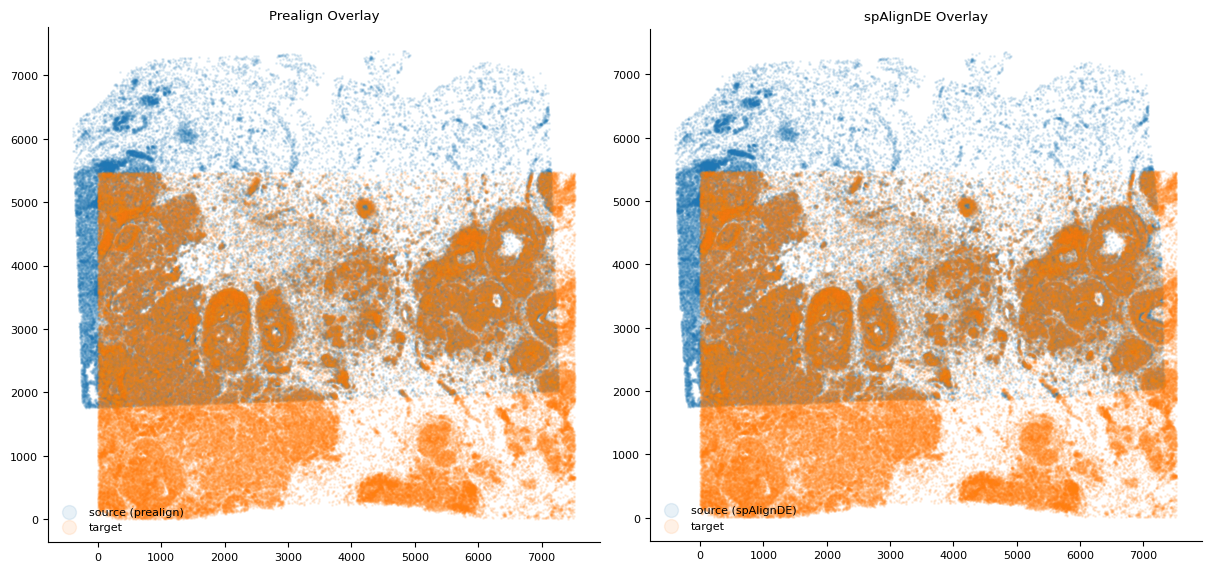

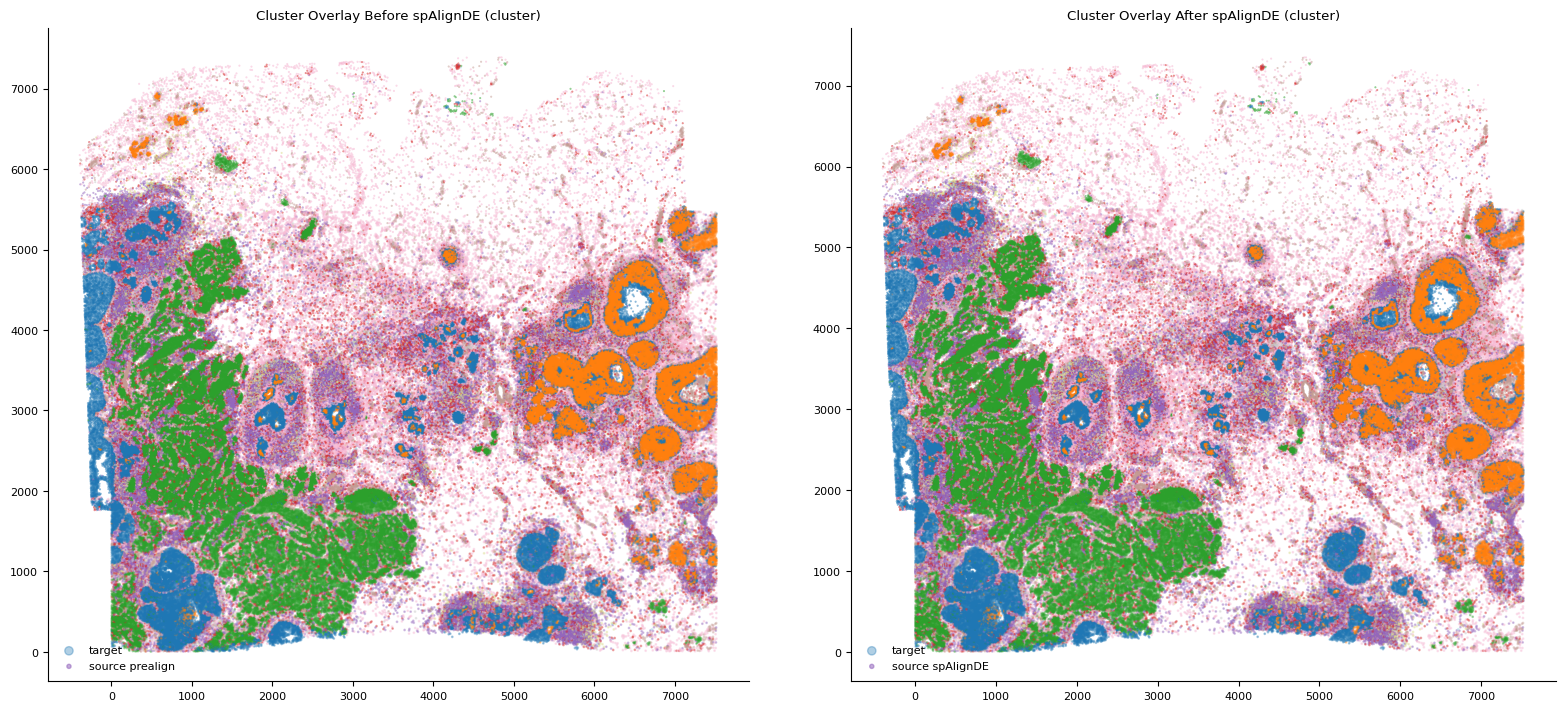

,cluster,n_cells,prealign_match_rate,lddmm_match_rate,prealign_mean_nn_dist,lddmm_mean_nn_dist,match_rate_gain
0,0,13230,0.515042,0.534165,72.209893,76.014326,0.019123
1,1,14372,0.817075,0.810534,51.665139,49.495095,-0.006540
2,2,17685,0.784789,0.807238,17.102187,17.263131,0.022448
3,3,10759,0.154847,0.161818,63.881622,63.902289,0.006971
4,4,22706,0.418215,0.428873,26.593135,27.048550,0.010658
5,5,9595,0.267223,0.288067,127.211921,125.529185,0.020844
6,6,21628,0.513501,0.523026,219.371204,215.069972,0.009525
7,7,3768,0.152070,0.165870,28.268953,28.826242,0.013800
8,8,3312,0.123188,0.128925,88.520631,86.184180,0.005737
9,9,575,0.015652,0.031304,35.657734,35.225765,0.015652


In [6]:
spAlignDE.plot_alignment_result(result)
spAlignDE.plot_cluster_alignment_result(result)
display(result.cluster_performance.sort_values("cluster"))

## Save aligned output

The full 313-gene AnnData is retained. Raw coordinates remain in
`obsm["spatial"]`; `x_prealigned`, `y_prealigned`, `x_aligned` and
`y_aligned` store the selected pre-alignment and final coordinates.

In [7]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
if OUTPUT_DIR == SUPP_DIR:
    aligned_path = OUTPUT_DIR / "breast_cancer_Rep2_to_Rep1_lambda_0p2_aligned.h5ad"
else:
    aligned_path = OUTPUT_DIR / "breast_cancer_Rep2_to_Rep1_aligned.h5ad"
result.adata.write_h5ad(aligned_path, compression="gzip")

output_columns = ["x_prealigned", "y_prealigned", "x_aligned", "y_aligned"]
sample = result.adata.obs["sample_id"].astype(str)
reference_mask = sample.eq(REFERENCE).to_numpy()
reference_output = result.adata.obs.loc[
    reference_mask, output_columns
].to_numpy(dtype=float)
reference_raw = np.asarray(result.adata.obsm["spatial"])[reference_mask]
assert np.allclose(reference_output[:, :2], reference_raw)
assert np.allclose(reference_output[:, 2:], reference_raw)

coordinates_path = OUTPUT_DIR / "alignment_coordinates.csv.gz"
result.adata.obs[
    ["cell_id", "sample_id", "cluster", *output_columns]
].to_csv(coordinates_path, compression="gzip")
def display_path(path):
    try:
        return path.relative_to(REPO_ROOT)
    except ValueError:
        return path


print("Saved:", display_path(aligned_path))
print("Saved:", display_path(coordinates_path))
print(result.adata.obs.loc[sample.eq(QUERY), output_columns].head())
print("Reference coordinates verified unchanged.")

Saved: outputs/breast_cancer_xenium/lambda_0p2/breast_cancer_Rep2_to_Rep1_aligned.h5ad
Saved: outputs/breast_cancer_xenium/lambda_0p2/alignment_coordinates.csv.gz
          x_prealigned  y_prealigned   x_aligned    y_aligned
spot_uid                                                     
Rep2_1      199.286883   2636.009252  190.813492  2654.594971
Rep2_2      201.240290   2617.966165  193.199997  2636.657227
Rep2_3      210.480804   2622.418204  202.180603  2641.156738
Rep2_4      210.626126   2633.456706  202.043762  2652.139160
Rep2_5      213.136250   2609.197813  205.128189  2628.025879
Reference coordinates verified unchanged.
